# Lab 02 — Heuristic Search on the Airline Network

**Objective.** Compare UCS, GBFS, A* and weighted A* using a Haversine heuristic, with route quality measured separately from search effort.

**Data.** The OpenFlights files used in Lab 01.

**Run.** From the course folder, run `cd all_experiments`, start Jupyter, open this notebook, and choose **Restart Kernel and Run All Cells**.

**Evidence.** `results/lab02/metrics.csv`, `heuristic_check.csv`, and `expanded_nodes.png`.

**Workflow**

1. Establish the UCS baseline.
2. Run GBFS and A* with the Haversine heuristic.
3. Check admissibility empirically.
4. Compare route quality and search effort.
5. Test weighted A* with an inflated heuristic.
6. Save the evidence.


## Setup

In [1]:
from heapq import heappop, heappush
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

from utils import ucs, gbfs, astar, haversine_km, load_openflights

ROOT = Path.cwd().parent
DATA = ROOT / "all_datasets"
RESULTS = ROOT / "results" / "lab02"
RESULTS.mkdir(parents=True, exist_ok=True)

_, _, coords, graph, _ = load_openflights(DATA / "lab01-03_airports.csv", DATA / "lab01-03_routes.csv")
queries = pd.read_csv("utils/search_queries.csv").head(3)
display(queries)

,query_id,start,goal
0,Q1,KUL,KEF
1,Q2,SIN,EZE
2,Q3,NRT,CPT


## Question 1 — Establish the baseline

Run UCS for the three standard queries. UCS is exact for non-negative costs, so its cost is
the reference every informed method is judged against.

In [2]:
def report(name, query, result):
    print(f"{query.query_id} {name:<5} {result.path_cost_km:>9,.1f} km  {result.expanded:>5} expanded   {' -> '.join(result.path)}")


baseline = {}
for query in queries.itertuples():
    baseline[query.query_id] = ucs(graph, query.start, query.goal)
    report("UCS", query, baseline[query.query_id])

Q1 UCS    11,461.3 km   1851 expanded   KUL -> HKT -> LED -> HEL -> KEF
Q2 UCS    17,817.4 km   3002 expanded   SIN -> JNB -> GRU -> EZE
Q3 UCS    14,813.3 km   3042 expanded   NRT -> HKG -> MRU -> CPT


**Result and interpretation.** UCS reproduces the Lab 1 distances (11,461 km, 17,817 km and 14,813 km).
These are the optimal costs; an informed method that returns more has traded quality for
speed.

## Question 2 — Implement the heuristic and run GBFS and A*

Use the great-circle distance from the current airport to the goal as $h(n)$. GBFS orders
the frontier by $h$ alone; A* by $g + h$. Write the heuristic as a function that fixes the
goal, then run both algorithms.

In [3]:
def heuristic_to(goal, weight=1.0):
    """h(airport) = weight x great-circle distance from the airport to the goal."""
    def h(airport):
        return weight * haversine_km(coords[airport]["latitude"], coords[airport]["longitude"],
                                     coords[goal]["latitude"], coords[goal]["longitude"])
    return h


informed = {}
for query in queries.itertuples():
    h = heuristic_to(query.goal)
    informed[query.query_id, "GBFS"] = gbfs(graph, query.start, query.goal, h)
    informed[query.query_id, "A*"] = astar(graph, query.start, query.goal, h)
    report("GBFS", query, informed[query.query_id, "GBFS"])
    report("A*", query, informed[query.query_id, "A*"])

Q1 GBFS   12,500.5 km      2 expanded   KUL -> LHR -> KEF
Q1 A*     11,461.3 km     69 expanded   KUL -> HKT -> LED -> HEL -> KEF
Q2 GBFS   17,817.4 km      3 expanded   SIN -> JNB -> GRU -> EZE
Q2 A*     17,817.4 km    151 expanded   SIN -> JNB -> GRU -> EZE
Q3 GBFS   15,811.3 km      3 expanded   NRT -> DOH -> JNB -> CPT
Q3 A*     14,813.3 km     63 expanded   NRT -> HKG -> MRU -> CPT


**Result and interpretation.** A* returns exactly the UCS cost on every query while expanding far fewer
states. GBFS expands only a handful of states, but two of its three routes are longer
because it ignores the distance already travelled.

## Question 3 — Check admissibility empirically

An admissible heuristic never overestimates the true remaining cost. Run Dijkstra once on
the reversed graph to get the exact cost from every airport *to* the goal, then compare
$h$ with that exact cost for ten airports spread across the range. Save `heuristic_check.csv`.

In [4]:
def reverse(graph):
    reversed_graph = {airport: [] for airport in graph}
    for airport, neighbours in graph.items():
        for neighbour, cost in neighbours:
            reversed_graph[neighbour].append((airport, cost))
    return reversed_graph


def cost_to_all(graph, start):
    """Dijkstra: cheapest cost from start to every reachable state."""
    best = {start: 0.0}
    frontier = [(0.0, start)]
    while frontier:
        cost, state = heappop(frontier)
        if cost > best[state]:
            continue
        for neighbour, edge in graph[state]:
            if cost + edge < best.get(neighbour, np.inf):
                best[neighbour] = cost + edge
                heappush(frontier, (cost + edge, neighbour))
    return best


reversed_graph = reverse(graph)
checks = []
for query in queries.itertuples():
    exact = cost_to_all(reversed_graph, query.goal)          # exact cost-to-go for every airport
    h = heuristic_to(query.goal)
    airports = sorted((a for a in exact if a != query.goal), key=exact.get)   # nearest first
    for airport in [airports[i] for i in np.linspace(0, len(airports) - 1, 10, dtype=int)]:
        checks.append({"query_id": query.query_id, "airport": airport, "goal": query.goal,
                       "haversine_km": h(airport), "shortest_route_km": exact[airport]})

check = pd.DataFrame(checks)
check["slack_km"] = check.shortest_route_km - check.haversine_km
check["admissible"] = check.slack_km >= -1e-6
check.to_csv(RESULTS / "heuristic_check.csv", index=False)
print("Admissibility violations:", int((~check.admissible).sum()), "of", len(check))
display(check.head(10).round(1))

Admissibility violations: 0 of 30


,query_id,airport,goal,haversine_km,shortest_route_km,slack_km,admissible
0,Q1,GLA,KEF,1347.5,1347.5,0.0,True
1,Q1,IBZ,KEF,3206.4,3244.5,38.1,True
2,Q1,GZP,KEF,4744.9,4745.7,0.8,True
3,Q1,TUU,KEF,5710.9,5847.1,136.2,True
4,Q1,OAK,KEF,6731.3,6893.0,161.8,True
5,Q1,ANC,KEF,5424.4,8137.0,2712.5,True
6,Q1,JSR,KEF,8696.8,9238.7,541.9,True
7,Q1,AKY,KEF,9163.0,10503.7,1340.7,True
8,Q1,ZCO,KEF,12238.3,12935.8,697.4,True
9,Q1,OTD,KEF,7561.2,30818.5,23257.4,True


**Result and interpretation.** Zero violations in thirty checks: the slack column is never negative. A
straight-line distance can never exceed the length of any actual route between the same two
points, so the Haversine heuristic is admissible and consistent by the triangle inequality. The
table is an empirical check; the geometry is the guarantee.

## Question 4 — Compare the methods

Put cost, hops, expanded nodes, maximum frontier and runtime for UCS, GBFS and A* in one
table, add the optimality gap relative to UCS, and save `metrics.csv`.

In [5]:
rows = []
for query in queries.itertuples():
    results = {"UCS": baseline[query.query_id], "GBFS": informed[query.query_id, "GBFS"], "A*": informed[query.query_id, "A*"]}
    for name, result in results.items():
        rows.append({"query_id": query.query_id, "algorithm": name, **result.as_dict(), "path": " -> ".join(result.path)})

metrics = pd.DataFrame(rows).drop(columns="found").rename(columns={"path_cost_km": "cost_km"})
ucs_cost = metrics[metrics.algorithm == "UCS"].set_index("query_id").cost_km
metrics["gap_pct"] = 100 * (metrics.cost_km / metrics.query_id.map(ucs_cost) - 1)
display(metrics.drop(columns="path").round(2))

ucs_rows, astar_rows = metrics[metrics.algorithm == "UCS"], metrics[metrics.algorithm == "A*"]
print("A* matches UCS on every query:", np.allclose(ucs_rows.cost_km.values, astar_rows.cost_km.values))
print("Mean A* expansion reduction vs UCS: {:.1%}".format(1 - astar_rows.expanded.mean() / ucs_rows.expanded.mean()))

,query_id,algorithm,hops,cost_km,expanded,max_frontier,runtime_ms,gap_pct
0,Q1,UCS,4,11461.35,1851,616,8.68,0.00
1,Q1,GBFS,2,12500.50,2,246,5.17,9.07
2,Q1,A*,4,11461.35,69,409,5.59,0.00
3,Q2,UCS,3,17817.36,3002,620,10.21,0.00
4,Q2,GBFS,3,17817.36,3,262,3.35,0.00
5,Q2,A*,3,17817.36,151,330,4.26,0.00
6,Q3,UCS,3,14813.32,3042,1018,9.24,0.00
7,Q3,GBFS,3,15811.29,3,234,3.15,6.74
8,Q3,A*,3,14813.32,63,496,3.41,0.00


A* matches UCS on every query: True
Mean A* expansion reduction vs UCS: 96.4%


**Result and interpretation.** A* keeps the UCS cost (gap 0 %) while expanding roughly 96 % fewer states.
GBFS is the cheapest to run but returns routes up to 9 % longer. The consistent Haversine heuristic
buys speed without giving up optimality; greed buys more speed by giving it up.

## Question 5 — Stress the guarantee

Repeat the queries with the inflated heuristic $1.5\,h$ (weighted A*). Explain when the
returned cost changes.

In [6]:
weighted = []
for query in queries.itertuples():
    result = astar(graph, query.start, query.goal, heuristic_to(query.goal, weight=1.5))
    weighted.append({"query_id": query.query_id, "algorithm": "Weighted A* (1.5h)", **result.as_dict(),
                     "path": " -> ".join(result.path)})

weighted = pd.DataFrame(weighted).drop(columns="found").rename(columns={"path_cost_km": "cost_km"})
weighted["gap_pct"] = 100 * (weighted.cost_km / weighted.query_id.map(ucs_cost) - 1)
metrics = pd.concat([metrics, weighted], ignore_index=True)
metrics.to_csv(RESULTS / "metrics.csv", index=False)
display(metrics[metrics.algorithm != "GBFS"][["query_id", "algorithm", "cost_km", "gap_pct", "expanded"]].round(2))

,query_id,algorithm,cost_km,gap_pct,expanded
0,Q1,UCS,11461.35,0.00,1851
2,Q1,A*,11461.35,0.00,69
3,Q2,UCS,17817.36,0.00,3002
5,Q2,A*,17817.36,0.00,151
6,Q3,UCS,14813.32,0.00,3042
8,Q3,A*,14813.32,0.00,63
9,Q1,Weighted A* (1.5h),12274.32,7.09,2
10,Q2,Weighted A* (1.5h),17817.36,0.00,3
11,Q3,Weighted A* (1.5h),14929.35,0.78,4


**Result and interpretation.** Multiplying $h$ by 1.5 makes it inadmissible: it can now overestimate the
remaining distance, so a route that *looks* closer to the goal is expanded first and
returned. The cost changes when the optimal route detours through airports that are
geographically further from the goal than a rival hop (Q1 and Q3); when the optimal route
already heads straight for the goal (Q2) nothing changes. Expansions fall to a handful; the
price is a route up to 7 % longer.

## Question 6 — Save the evidence

Save an expanded-nodes figure for UCS, GBFS and A*. The two tables were saved above.

Saved: ['expanded_nodes.png', 'heuristic_check.csv', 'metrics.csv']


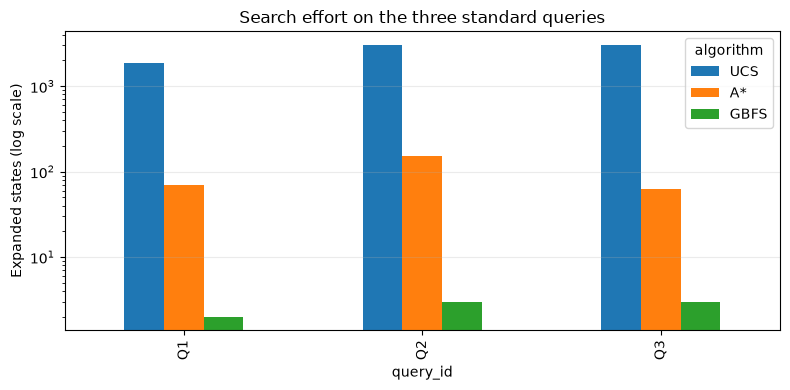

In [7]:
effort = metrics[metrics.algorithm.isin(["UCS", "A*", "GBFS"])].pivot(index="query_id", columns="algorithm", values="expanded")
ax = effort[["UCS", "A*", "GBFS"]].plot.bar(figsize=(8, 4), logy=True)
ax.set(ylabel="Expanded states (log scale)", title="Search effort on the three standard queries")
ax.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.savefig(RESULTS / "expanded_nodes.png", dpi=160)
print("Saved:", sorted(p.name for p in RESULTS.iterdir()))

**Result and interpretation.** Evidence: `results/lab02/metrics.csv`, `heuristic_check.csv`,
`expanded_nodes.png` and this executed notebook. Expanded-state counts are the primary
effort measure; wall-clock times depend on the machine.

## Submission checklist

- Restart the kernel and run all cells without errors.
- Submit this executed notebook and the generated `results/lab02/` folder.
- Add a short conclusion: Explain why A* matches UCS, why GBFS can return a longer route, and what guarantee is lost when the heuristic is multiplied by 1.5.
